# Projet Data Science : Ames Housing (House Prices)

**Méthodologie :** CRISP-ML(Q)

Ce notebook retrace l'intégralité de notre pipeline d'apprentissage automatique pour prédire le prix des maisons à Ames, de l'exploration initiale des données jusqu'au déploiement (soumission Kaggle).

In [1]:
# Importation des librairies standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Librairies de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

## Phase 1 : Business & Data Understanding (Analyse Exploratoire)
Avant de nettoyer ou de modéliser, nous devons comprendre le problème métier et la structure de nos données.
1. **La variable cible (SalePrice) :** Quelle est sa distribution ?
2. **Les valeurs aberrantes :** Y a-t-il des transactions anormales qui pourraient fausser notre modèle ?
3. **Corrélations :** Quelles sont les variables qui semblent le plus influencer le prix ?

Dimensions du jeu d'entraînement : (1460, 81)


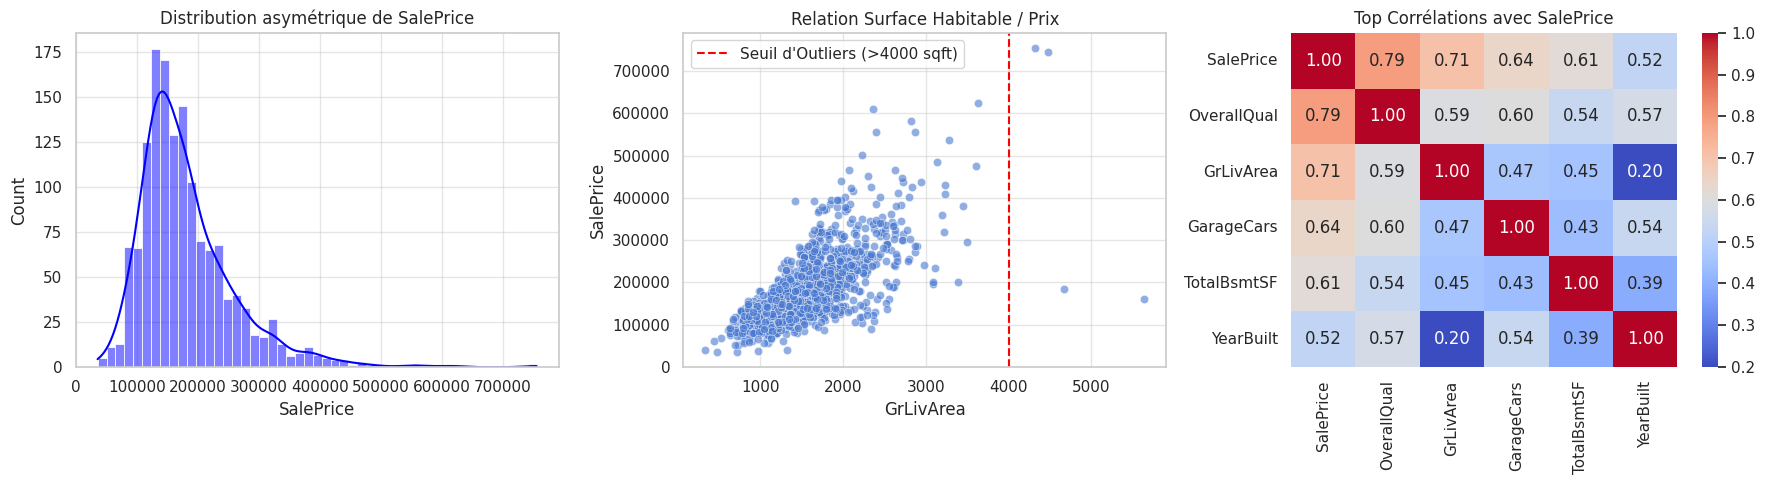

In [2]:
# Chargement initial pour l'exploration
train_raw = pd.read_csv('Data/train.csv')
test_raw = pd.read_csv('Data/test.csv')

print(f"Dimensions du jeu d'entraînement : {train_raw.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution de la variable cible
sns.histplot(train_raw['SalePrice'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution asymétrique de SalePrice')

# 2. Identification des Outliers (Surface vs Prix)
sns.scatterplot(data=train_raw, x='GrLivArea', y='SalePrice', ax=axes[1], alpha=0.6)
axes[1].axvline(x=4000, color='red', linestyle='--', label='Seuil d\'Outliers (>4000 sqft)')
axes[1].set_title('Relation Surface Habitable / Prix')
axes[1].legend()

# 3. Matrice de corrélation des top variables numériques
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
corr_matrix = train_raw[top_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Top Corrélations avec SalePrice')

plt.tight_layout()
plt.show()

**Conclusions de la Phase 1 :**
* La cible `SalePrice` n'est pas normale. Nous devrons appliquer une transformation logarithmique (`np.log1p`).
* Il y a des valeurs aberrantes massives pour les maisons de plus de 4000 pieds carrés. Nous devons les supprimer.
* Des variables comme `OverallQual` (Qualité) et `GrLivArea` (Surface) sont fortement corrélées au prix.

## Phase 2 : Data Engineering (Préparation des données)
Sur la base de notre exploration, nous allons nettoyer le dataset complet.

In [3]:
# 1. Traitement des Outliers identifiés en Phase 1
train_clean = train_raw[train_raw['GrLivArea'] <= 4000].copy()

# 2. Transformation de la variable cible
y_train = np.log1p(train_clean['SalePrice'])
train_clean.drop(['SalePrice', 'Id'], axis=1, inplace=True)

test_ids = test_raw['Id']
test_clean = test_raw.drop(['Id'], axis=1).copy()

# Concaténation pour traiter les NAs et encoder uniformément
ntrain = train_clean.shape[0]
all_data = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)

# 3. Gestion experte des valeurs manquantes (NAs)
# Selon le dictionnaire métier, NA = "Absence de l'équipement" pour ces variables
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cols_none:
    all_data[col] = all_data[col].fillna('None')

# Pour les surfaces liées à une absence, NA = 0
cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
             'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in cols_zero:
    all_data[col] = all_data[col].fillna(0)

# Reste des NAs : Médiane (numériques) et Mode (catégorielles)
num_cols = all_data.select_dtypes(exclude=['object']).columns
all_data[num_cols] = all_data[num_cols].fillna(all_data[num_cols].median())

cat_cols = all_data.select_dtypes(include=['object']).columns
for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# 4. Target Encoding pour 'Neighborhood' (Calculé uniquement sur le Train !)
train_temp = all_data.iloc[:ntrain].copy()
train_temp['Target'] = y_train.values
neighborhood_means = train_temp.groupby('Neighborhood')['Target'].mean().to_dict()

all_data['Neighborhood_Enc'] = all_data['Neighborhood'].map(neighborhood_means)
all_data.drop(['Neighborhood'], axis=1, inplace=True)

# 5. One-Hot Encoding pour le reste
all_data = pd.get_dummies(all_data, drop_first=True)

# Reséparation
X_train = all_data.iloc[:ntrain]
X_test = all_data.iloc[ntrain:]

## Phase 3 : Feature Selection (Modélisation Avancée)
Nous avons généré des centaines de colonnes avec le One-Hot Encoding. Pour éviter l'overfitting (la malédiction de la dimensionnalité), nous utilisons une régression Lasso (pénalité L1) pour sélectionner automatiquement les variables ayant un vrai signal.

In [4]:
# 1. Standardisation (Obligatoire pour Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Modèle Lasso avec Cross-Validation intégrée
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# 3. Extraction des variables conservées
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
selected_features = lasso_coefs[lasso_coefs != 0].index

print(f"Alpha optimal trouvé : {lasso.alpha_:.4f}")
print(f"Variables conservées : {len(selected_features)} sur {X_train.shape[1]}")

# Application du filtre sur nos datasets
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Alpha optimal trouvé : 0.0043
Variables conservées : 73 sur 235


## Phase 4 : Modélisation (XGBoost), Tuning et Déploiement
Nos données sont prêtes. Nous allons entraîner un algorithme de boosting (XGBoost) et utiliser GridSearchCV pour trouver ses meilleurs hyperparamètres (le "sweet spot").
Enfin, nous inversons la transformation algorithmique pour générer notre soumission.

In [5]:
# 1. Grille d'hyperparamètres
param_grid = {
    'n_estimators': [500, 800],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb = XGBRegressor(random_state=42)

# 2. Recherche du meilleur modèle (Cross-Validation)
print("Recherche des meilleurs hyperparamètres (GridSearch)...")
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error',
                           n_jobs=-1)

grid_search.fit(X_train_selected, y_train)

best_xgb = grid_search.best_estimator_
best_score = -grid_search.best_score_

print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"RMSE de validation estimé : {best_score:.4f}")

# 3. Prédictions finales
log_preds = best_xgb.predict(X_test_selected)

# 4. Déploiement : Inversion du Log (expm1) et fichier Kaggle
final_preds = np.expm1(log_preds)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})
submission.to_csv('M4.1_XGBoost.csv', index=False)

print("\nDéploiement réussi ! Le fichier 'submission_crisp_ml_final.csv' est prêt pour Kaggle.")
submission.head()

Recherche des meilleurs hyperparamètres (GridSearch)...
Meilleurs hyperparamètres : {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}
RMSE de validation estimé : 0.1184

Déploiement réussi ! Le fichier 'submission_crisp_ml_final.csv' est prêt pour Kaggle.


,Id,SalePrice
0,1461,125154.867188
1,1462,158889.000000
2,1463,188046.921875
3,1464,191913.343750
4,1465,190371.015625
